# EDA: what time scale separates spam from legit traffic?

`config/settings.py` currently guesses `BEHAVIORAL_SHORT_WINDOW="5min"` and
`BEHAVIORAL_LONG_WINDOW="1h"` for `features/behavioral.py`'s rolling-window
sender features. That was a reasonable starting point, not a data-driven
choice. This notebook checks it against real ingested data before the
window ladder gets locked into the Feast schema.

**SS7 excluded for now** - `ingestion/ss7.py` has no `clean()` yet, so
there's no `data/processed/SS7/messages.csv` to build from. SMPP only.

Uses the **reassembled** (one row per logical message, not per part)
output, same reasoning `features/behavioral.py` will need: counting raw
parts would double/triple-count one multipart message as N sends from the
same sender, biasing exactly the volumetric signal being measured here.

**Label caveat this notebook respects** (see `labels/rule_labels.py`):
only rows with `rule_evaluated==True` have a trustworthy `rule_flagged`
label. Rows never evaluated (or only hit a SmartWhitelist pre-check) are
dropped from the spam-vs-not comparison entirely, not treated as
negatives.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("..").resolve()))  # so `features.*` imports work from notebooks/

from features.message_reassembly import run_reassembly

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

MESSAGES_PATH = Path("..") / "data" / "processed" / "SS7" / "messages.csv"
FEATURES_DIR = Path("..") / "data" / "processed" / "SS7" / "features"
LABELS_DIR = Path("..") / "data" / "processed" / "SS7" / "labels"

# Candidate window sizes. 7d/30d deliberately NOT included - the real data
# on disk (data/raw/SMPP/{0208,0308}) spans ~2 days, so a multi-day window
# would be near-identical to lifetime count for almost every row right now.
# Re-add once more days of data land.
WINDOWS = ["5min", "15min", "1h", "6h", "24h"]

## Load reassembled messages (builds `messages.csv` via `run_reassembly` if it doesn't exist yet)

In [3]:
if MESSAGES_PATH.exists():
    messages = pd.read_csv(MESSAGES_PATH, low_memory=False)
else:
    messages = run_reassembly(FEATURES_DIR, LABELS_DIR, MESSAGES_PATH)

messages["timestamp"] = pd.to_datetime(messages["timestamp"], format="mixed")

print(f"{len(messages)} logical messages, {messages['originator'].nunique()} distinct senders")
print(f"timestamp range: {messages['timestamp'].min()} .. {messages['timestamp'].max()}")

2742301 logical messages, 834 distinct senders
timestamp range: 2026-08-02 00:00:00 .. 2026-08-03 23:59:59


## Point-in-time rolling window counts + inter-arrival gaps

`count_<window>` = sender's message count in the trailing window, as-of
each message's own timestamp (inclusive of itself, `closed="right"`) -
same semantics `features/behavioral.py`'s rolling windows will need, so
this measures the actual feature shape, not a proxy for it.

`gap_seconds` = seconds since this sender's previous message (NaN for a
sender's first message).

In [ ]:
def add_rolling_counts(df: pd.DataFrame, windows: list[str]) -> pd.DataFrame:
    # groupby(...).rolling(...) does NOT preserve the original row index -
    # it returns a MultiIndex of (originator, timestamp) instead, and real
    # timestamps are NOT unique (multiple messages can land in the same
    # second), so reassigning via index alignment fails either way (with or
    # without on="timestamp") with "cannot reindex on an axis with
    # duplicate labels". Fix: sort by (originator, timestamp) explicitly -
    # this IS the row order groupby(sort=True).rolling() produces
    # internally (verified) - then assign the result POSITIONALLY
    # (.to_numpy()) instead of relying on index alignment at all.
    df = df.sort_values(["originator", "timestamp"]).reset_index(drop=True)
    df["_one"] = 1
    for w in windows:
        df[f"count_{w}"] = (
            df.groupby("originator")
            .rolling(w, on="timestamp", closed="right")["_one"]
            .sum()
            .to_numpy()
        )
    return df.drop(columns="_one")


def add_interarrival_gap(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(["originator", "timestamp"])
    df["gap_seconds"] = df.groupby("originator")["timestamp"].diff().dt.total_seconds()
    return df


messages = add_rolling_counts(messages, WINDOWS)
messages = add_interarrival_gap(messages)
messages.head(3)

,originator,originator_ton,originator_npi,destination,text,timestamp,system_id,dcs,messaging_mode,source_ip,dest_ip,instance_id,virtual_gt,record_id,source,text_decode_failed,fraud_type,rule_evaluated,rule_flagged,message_part_count,message_expected_parts,message_partial,count_5min,count_15min,count_1h,count_6h,count_24h,gap_seconds
0,22281,1.0,1.0,6.011128e+11,Your BeONE verification code is: 898040. Valid...,2026-08-02 00:01:14.853,BeONE,0.0,0.0,43.217.191.118,172.28.17.236,2151132865719070_20260802000114_master1,9933365976421380_20260113163656_master1,stg_smpp_20260802_0000#0971229694692232_202608...,SMPP,False,NaN,False,NaN,1,1,False,1.0,1.0,1.0,1.0,1.0,NaN
1,22281,1.0,1.0,6.011234e+11,Welcome to BeONE! Phone: 601123351500 Pwd: F2f...,2026-08-02 00:03:20.827,BeONE,0.0,0.0,43.217.191.118,172.28.17.236,7331709326533797_20260802000320_master1,9933365976421380_20260113163656_master1,stg_smpp_20260802_0000#0110052257670964_202608...,SMPP,False,NaN,False,NaN,1,1,False,2.0,2.0,2.0,2.0,2.0,125.974
2,22281,1.0,1.0,6.011128e+11,Your BeONE verification code is: 859955. Valid...,2026-08-02 00:03:30.348,BeONE,0.0,0.0,43.217.191.118,172.28.17.236,3240519621513416_20260802000330_master1,9933365976421380_20260113163656_master1,stg_smpp_20260802_0000#0904805842165688_202608...,SMPP,False,NaN,False,NaN,1,1,False,3.0,3.0,3.0,3.0,3.0,9.521


## Labeled pool: spam vs not-spam via `decision`, not `rule_evaluated`

**Correction from the previous version of this notebook:** the
`rule_evaluated`/`rule_flagged` columns (rule/rule_name-based, from
`labels/rule_labels.py`) have ZERO real negatives in this data - every
`rule_evaluated==True` row is also `rule_flagged==True` (checked across
all 5.5M reassembled messages). Falling back to "rest of traffic" as
not-spam was wrong: that pool is mostly rows that were never confirmed
either way, not confirmed clean.

`decision` is the fix - checked directly against all 6,045,250 raw op-4
SMPP rows: it's populated on **every single one** (6,042,073 `decision==0`
/ 3,177 `decision==1`, zero NaN). It's just not in the processed pipeline
output today (`ingestion/smpp.py`'s `map_to_canonical()` reads it only as
an internal ingredient for `is_rule_evaluated()`/`build_rule_labels()`,
never returns it - see `LABEL_SOURCE_COLS`). Pulled back in directly from
`data/raw/SMPP` below and joined on `record_id`.

**spam** = `rule_flagged==True` (fraud_type=="spam", 2,693 confirmed
messages). **not-spam** = `decision==0` (rule engine evaluated and
allowed) AND not already in the spam set. Anything that matches neither -
should be ~0 given decision has no NaNs - gets printed and excluded, not
silently folded into either class.

Caveat carried over from `labels/rule_labels.py`: `decision==0` includes
`SW_*` whitelist-bypassed rows (content never actually inspected), not
only genuinely content-checked-clean ones. Good enough as the not-spam
baseline for this descriptive EDA; revisit before using it as a supervised
training label.

In [ ]:
# decision isn't in messages.csv (see markdown above) - rebuild record_id
# the same way ingestion/run_ingest.py does ("{filestem}#{raw index}") and
# join it back on. usecols keeps this to 3 columns across 48 raw files -
# ~40s total, not a full re-ingest.
RAW_SMPP_DIR = Path("..") / "data" / "raw" / "SMPP"

decision_parts = []
for raw_path in sorted(RAW_SMPP_DIR.rglob("*.csv")):
    raw = pd.read_csv(raw_path, usecols=["index", "smpp_operation", "decision"], low_memory=False)
    raw = raw[raw["smpp_operation"] == 4]
    decision_parts.append(pd.DataFrame({
        "record_id": raw_path.stem + "#" + raw["index"].astype(str),
        "decision": raw["decision"],
    }))
decision_df = pd.concat(decision_parts, ignore_index=True)

# a logical (reassembled) message can span multiple raw parts/decisions -
# same "take the first part" approximation message_reassembly.py already
# uses for other non-explicitly-reconciled columns (system_id, dcs, ...).
decision_df = decision_df.drop_duplicates(subset="record_id", keep="first")

messages = messages.merge(decision_df, on="record_id", how="left")
print(messages["decision"].value_counts(dropna=False))

decision
0.0    5503511
1.0       2410
Name: count, dtype: int64


In [ ]:
spam = messages[messages["rule_flagged"] == True]
not_spam = messages[(messages["decision"] == 0) & (messages["rule_flagged"] != True)]
unclassified = messages[messages["decision"].isna() & (messages["rule_flagged"] != True)]

print(f"confirmed spam (rule_flagged==True): {len(spam)}")
print(f"confirmed not-spam (decision==0): {len(not_spam)}")
print(f"unclassified (decision is NaN, matches neither): {len(unclassified)} - excluded from comparison")

labeled = pd.concat([spam, not_spam]).copy()
labeled["rule_flagged"] = labeled["rule_flagged"] == True

print(f"{len(labeled)} rows in comparison pool "
      f"({labeled['rule_flagged'].sum()} spam / {(~labeled['rule_flagged']).sum()} not-spam)")

confirmed spam (rule_flagged==True): 2693
confirmed not-spam (decision==0): 5503228
unclassified (decision is NaN, matches neither): 0 - excluded from comparison
5505921 rows in comparison pool (2693 spam / 5503228 not-spam)


## Inter-arrival gap: spam vs not-spam

In [ ]:
def summarize(df, col, label_col="rule_flagged"):
    return (
        df.groupby(label_col)[col]
        .describe(percentiles=[0.5, 0.9, 0.99])
        .rename(index={True: "spam", False: "not-spam"})
    )

summarize(labeled, "gap_seconds")

,count,mean,std,min,50%,90%,99%,max
rule_flagged,,,,,,,,
spam,2693.0,0.865521,1.670004,0.0,0.566,1.696,8.5474,24.117


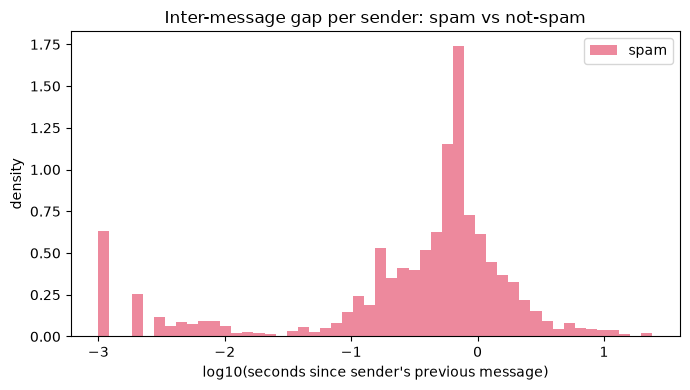

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
for flagged, color, label in [(True, "crimson", "spam"), (False, "steelblue", "not-spam")]:
    gaps = labeled.loc[labeled["rule_flagged"] == flagged, "gap_seconds"].dropna()
    gaps = gaps[gaps > 0]  # log-scale can't plot 0
    if not gaps.empty:
        ax.hist(np.log10(gaps), bins=50, alpha=0.5, density=True, color=color, label=label)
ax.set_xlabel("log10(seconds since sender's previous message)")
ax.set_ylabel("density")
ax.set_title("Inter-message gap per sender: spam vs not-spam")
ax.legend()
fig.tight_layout()

## Window counts: spam vs not-spam, per window size

Whichever window size shows the clearest separation in medians/p90/p99 below is the one actually worth keeping in the feature schema.

In [ ]:
for w in WINDOWS:
    print(f"--- count_{w} ---")
    display(summarize(labeled, f"count_{w}"))

--- count_5min ---


,count,mean,std,min,50%,90%,99%,max
rule_flagged,,,,,,,,
spam,2693.0,389.896398,177.848785,26.0,384.0,605.0,802.08,2851.0


--- count_15min ---


,count,mean,std,min,50%,90%,99%,max
rule_flagged,,,,,,,,
spam,2693.0,1171.209432,510.889225,99.0,1168.0,1817.8,2403.04,5038.0


--- count_1h ---


,count,mean,std,min,50%,90%,99%,max
rule_flagged,,,,,,,,
spam,2693.0,4608.839955,1891.886665,248.0,4713.0,7396.6,8907.0,9191.0


--- count_6h ---


,count,mean,std,min,50%,90%,99%,max
rule_flagged,,,,,,,,
spam,2693.0,24132.489788,11185.240455,248.0,25793.0,41518.0,45324.08,45508.0


--- count_24h ---


,count,mean,std,min,50%,90%,99%,max
rule_flagged,,,,,,,,
spam,2693.0,68247.482362,32169.513566,248.0,83543.0,103947.6,112426.0,113163.0


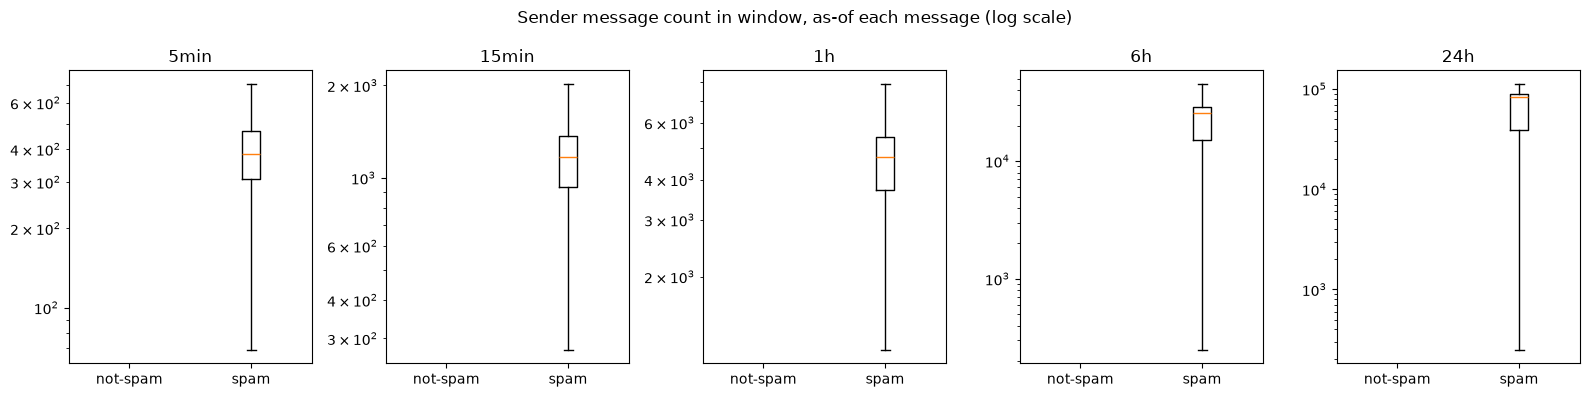

In [ ]:
fig, axes = plt.subplots(1, len(WINDOWS), figsize=(3.2 * len(WINDOWS), 4), sharey=False)
for ax, w in zip(axes, WINDOWS):
    col = f"count_{w}"
    data = [
        labeled.loc[labeled["rule_flagged"] == False, col].dropna(),
        labeled.loc[labeled["rule_flagged"] == True, col].dropna(),
    ]
    ax.boxplot(data, tick_labels=["not-spam", "spam"], showfliers=False)
    ax.set_title(w)
    ax.set_yscale("log")
fig.suptitle("Sender message count in window, as-of each message (log scale)")
fig.tight_layout()